# What to look out for when trying to jay-walk in Philadelphia
## What does crash data tell us about when and where to cross the street?

**Author:** Fiona Herzog  
- `collision_crash_2020_2024.csv` — PennDOT crash records, Philadelphia, 2020–2024 (35,454 crashes, 5,109 pedestrian-involved)
- `red_light_camera_locations.csv` — City of Philadelphia OTIS, 108 camera units at 27 intersections
- `Rubbish_Recyc_Coll_Bnd.geojson` — Philadelphia district boundaries

---

Since coming to Philadelphia, I have noticed that people are generally frequent jay walkers, in spite of (at least in my observations), cars being a lot less courteous to pedestrians compared to my home in Los Angeles. Thus, this data story will examine what are the conditions that result in the most frequent pedestrian accidents at intersections.

Philadelphia recorded **5,109 pedestrian-involved crashes** between 2020 and 2024. 256 of those pedestrians died. This notebook does not advocate for jaywalking — but it does take seriously that people cross mid-block and against signals all the time, and that understanding *when* and *where* those crossings are most dangerous is genuinely useful information.

**Subquestions:**
- **Q1** Is it actually more dangerous to cross mid-block than at an intersection?
- **Q2** What time of day and day of week concentrates pedestrian crash risk?
- **Q3** Does darkness multiply injury severity — and by how much?
- **Q4** At camera-monitored intersections specifically, which locations have the worst pedestrian crash records?


---
## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MPoly
from matplotlib.collections import PatchCollection
from scipy import stats
import json
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

---
## Data loading and preparation

We filter PennDOT crash records to Philadelphia (municipality code 67301) and isolate the
pedestrian-involved subset. The PennDOT `pedestrian` flag is set to 1 any time a pedestrian
was a party to the crash — this includes both intersection crossings and mid-block events.

**Key fields for this analysis:**

| Field | What it records |
|---|---|
| `pedestrian` | 1 if a pedestrian was involved |
| `intersection` | 1 if crash occurred at or within an intersection |
| `signalized_int` | 1 if the intersection had a traffic signal |
| `illumination_dark` | 1 if lighting conditions were dark at time of crash |
| `hit_run` | 1 if the striking vehicle fled the scene |
| `fatal` | 1 if crash resulted in at least one fatality |
| `max_severity_level` | 1=Fatal, 2=Suspected Serious Injury, 3=Suspected Minor Injury, 4=Possible Injury, 0=Property Damage Only |
| `day_of_week` | 1=Sunday through 7=Saturday |
| `time_of_day` | Military time (HHMM), not recorded for all crashes |


In [3]:
crashes = pd.read_csv("data/collision_crash_2020_2024.csv")
crashes = crashes[crashes["municipality"] == 67301].copy()

# Severity labels — PennDOT uses both code 1 and 8 for fatal; merge them
SEV_MAP = {
    1: "Fatal", 8: "Fatal",
    2: "Susp. Serious Injury",
    3: "Susp. Minor Injury",
    4: "Possible Injury",
    0: "Property Damage Only",
}
crashes["severity"] = crashes["max_severity_level"].map(SEV_MAP).fillna("Unknown")

# Pedestrian subset
ped = crashes[crashes["pedestrian"] == 1].copy()

# Derive hour from time_of_day (HHMM format)
ped["hour"] = pd.to_numeric(ped["time_of_day"], errors="coerce") // 100

DAY_LABELS = {1:"Sun", 2:"Mon", 3:"Tue", 4:"Wed", 5:"Thu", 6:"Fri", 7:"Sat"}
ped["day_label"] = ped["day_of_week"].map(DAY_LABELS)

print(f"Total Philadelphia crashes (2020–2024): {len(crashes):,}")
print(f"Pedestrian-involved crashes:            {len(ped):,} ({len(ped)/len(crashes)*100:.1f}%)")
print(f"Pedestrian fatalities:                  {ped['fatal'].sum():,} ({ped['fatal'].mean()*100:.1f}% of ped crashes)")
print(f"Pedestrian crashes per year:")
print(ped.groupby("crash_year")
        .agg(crashes=("crn","count"), fatal=("fatal","sum"))
        .to_string())


Total Philadelphia crashes (2020–2024): 35,454
Pedestrian-involved crashes:            5,109 (14.4%)
Pedestrian fatalities:                  256 (5.0% of ped crashes)
Pedestrian crashes per year:
            crashes  fatal
crash_year                
2020            977     49
2021            980     41
2022           1018     58
2023           1059     58
2024           1075     50


---
## Q1 — Is crossing mid-block actually more dangerous than crossing at an intersection?

The conventional wisdom is that intersections are more dangerous because more vehicles converge there.
But that ignores two things: first, mid-block crossings are uncontrolled — no signal, no crosswalk markings,
drivers not expecting a pedestrian. Second, when a vehicle *does* hit a pedestrian mid-block,
it is usually traveling faster and at full lane speed rather than decelerating for a signal.

We compare three crossing contexts using PennDOT's `intersection` and `signalized_int` fields:
- **Signalized intersection** — traffic light present
- **Unsignalized intersection** — stop sign or uncontrolled crossing
- **Mid-block** — not at any intersection

The metric that matters for a pedestrian is not crash count (more people cross at intersections,
so raw volume is biased) but **fatal rate per crash** — given that a crash happens, how likely is it to kill you?


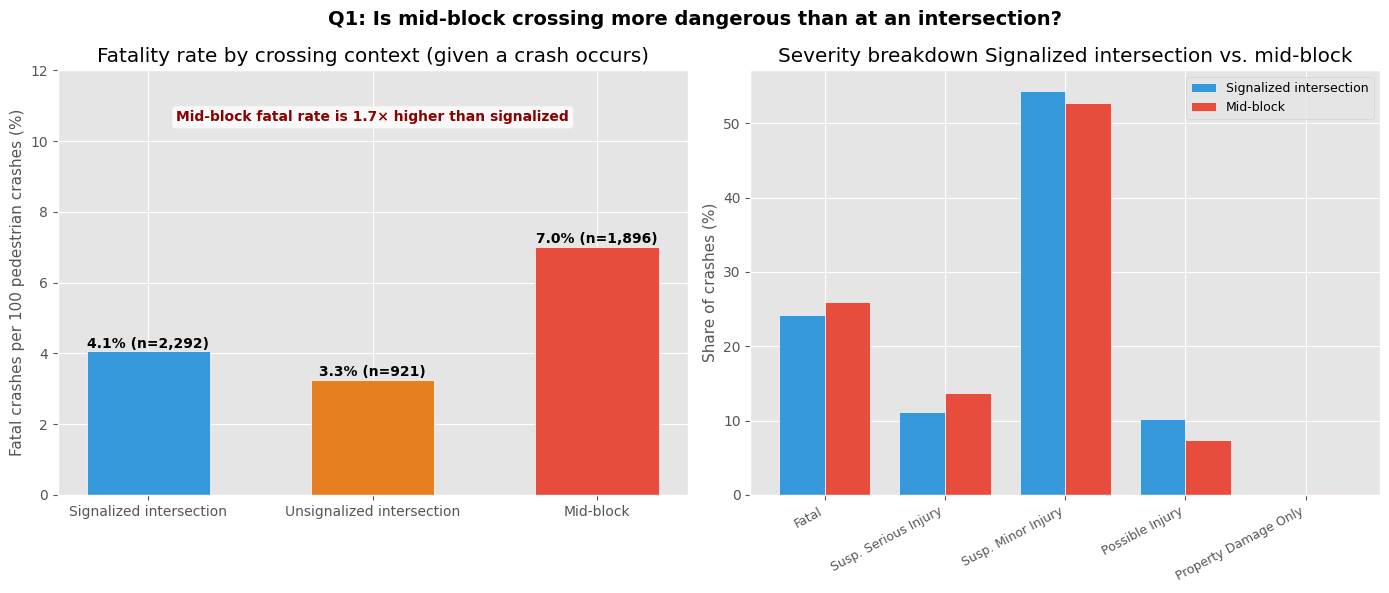

In [4]:
# Three crossing contexts
sig   = ped[ped["signalized_int"] == 1]
unsig = ped[(ped["intersection"] == 1) & (ped["signalized_int"] == 0)]
midblk= ped[ped["intersection"] == 0]

contexts = ["Signalized intersection", "Unsignalized intersection", "Mid-block"]
counts   = [len(sig), len(unsig), len(midblk)]
fatals   = [sig["fatal"].sum(), unsig["fatal"].sum(), midblk["fatal"].sum()]
fatal_rates = [f/n*100 for f, n in zip(fatals, counts)]

sev_order = ["Fatal", "Susp. Serious Injury", "Susp. Minor Injury",
             "Possible Injury", "Property Damage Only"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Q1: Is mid-block crossing more dangerous than at an intersection?",
             fontsize=14, fontweight="bold")

# ── Fatal rate by crossing context ───────────────────────────────────────────
ax = axes[0]
colors = ["#3498db", "#e67e22", "#e74c3c"]
bars = ax.bar(contexts, fatal_rates, color=colors, edgecolor="white", width=0.55)
ax.set_ylabel("Fatal crashes per 100 pedestrian crashes (%)", fontsize=11)
ax.set_title("Fatality rate by crossing context (given a crash occurs)")
ax.set_ylim(0, 12)

for bar, rate, n in zip(bars, fatal_rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.1, f"{rate:.1f}% (n={n:,})", ha="center", fontsize=10, fontweight="bold")

ax.text(0.5, 0.88,
        f"Mid-block fatal rate is {fatal_rates[2]/fatal_rates[0]:.1f}× higher than signalized",
        transform=ax.transAxes, ha="center", fontsize=10, color="darkred",
        fontweight="bold", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# ── Severity breakdown: signalized vs mid-block ───────────────────────────────
ax = axes[1]
sig_sev   = (sig["severity"].value_counts(normalize=True)*100).reindex(sev_order, fill_value=0)
mid_sev   = (midblk["severity"].value_counts(normalize=True)*100).reindex(sev_order, fill_value=0)

x = np.arange(len(sev_order))
w = 0.38
ax.bar(x - w/2, sig_sev.values,   width=w, label="Signalized intersection",
       color="#3498db", edgecolor="white")
ax.bar(x + w/2, mid_sev.values,   width=w, label="Mid-block",
       color="#e74c3c", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(sev_order, rotation=28, ha="right", fontsize=9)
ax.set_ylabel("Share of crashes (%)", fontsize=11)
ax.set_title("Severity breakdown Signalized intersection vs. mid-block")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("q1_crossing_context.png", dpi=150, bbox_inches="tight")
plt.show()


Mid-block crashes have a **fatality rate nearly twice that of crashes at signalized intersections**
(7.0% vs 4.1% for signalized; 5.5% for unsignalized).
The breakdown confirms this is not just a fatal-count difference.
Mid-block crashes show a higher share of both Fatal and Suspected Serious Injury outcomes and a lower share of Property Damage Only events.

I suspect it is due to the following. A driver hitting a pedestrian mid-block is traveling at or near full road speed, is not slowing for a signal, and is not expecting a pedestrian in the lane.

At a signalized intersection, vehicles are at some stage of deceleration or acceleration, and drivers are at higher cognitive alert for crossing pedestrians.

**The implication for crossing decisions:** if you are going to cross outside of a crosswalk, the safest version of that is at a signalized intersection (crossing with the signal but from a non-designated crossing point) — not mid-block.


---
## Q2 — What time of day and day of week concentrates pedestrian crash risk?

Crashes are not uniformly distributed across time. Pedestrian volume peaks during commute hours,
but driver behavior — speed, attention, alcohol involvement — varies independently.
If fatal crashes concentrate at times different from total crash volume, that tells us something
specific about which hours carry the highest *per-crossing* risk.

Note that `time_of_day` is only recorded in 1,912 of 5,109 pedestrian crashes (~37%).
The hour-level analysis uses only the subset with recorded times.
Day-of-week data is complete for all records and is used for the weekly pattern analysis.


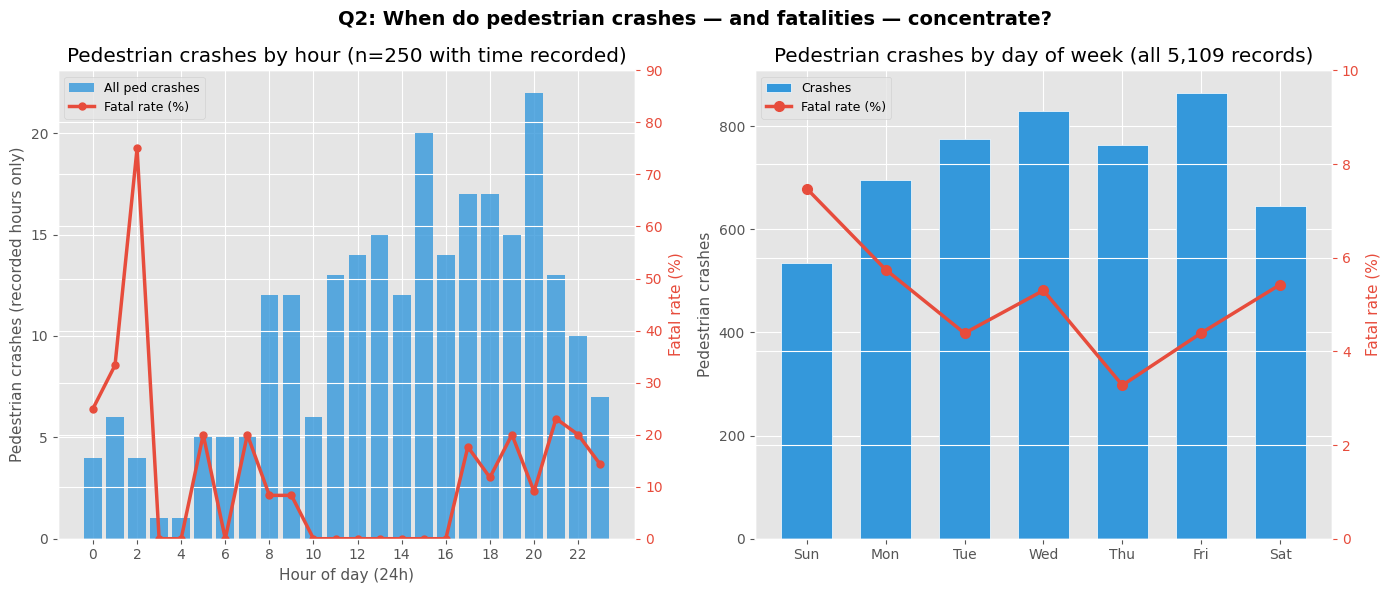

Fatal rate by hour (top 5 highest):
 hour  crashes  fatal  fatal_rate
  2.0        4      3   75.000000
  1.0        6      2   33.333333
  0.0        4      1   25.000000
 21.0       13      3   23.076923
  7.0        5      1   20.000000

Fatal rate by day:
day_label  crashes  fatal  fatal_rate
      Sun      535     40    7.476636
      Mon      696     40    5.747126
      Tue      775     34    4.387097
      Wed      830     44    5.301205
      Thu      763     25    3.276540
      Fri      865     38    4.393064
      Sat      645     35    5.426357


In [5]:
ped_hour  = ped.dropna(subset=["hour"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Q2: When do pedestrian crashes — and fatalities — concentrate?",
             fontsize=14, fontweight="bold")

# ── Hour of day: crashes vs fatalities ───────────────────────────────────────
ax = axes[0]
by_hour = ped_hour.groupby("hour").agg(
    crashes=("crn", "count"),
    fatal  =("fatal","sum")
).reset_index()
by_hour["fatal_rate"] = by_hour["fatal"] / by_hour["crashes"] * 100

ax.bar(by_hour["hour"], by_hour["crashes"], color="#3498db",
       edgecolor="none", alpha=0.8, label="All ped crashes")

ax2 = ax.twinx()
ax2.plot(by_hour["hour"], by_hour["fatal_rate"],
         color="#e74c3c", linewidth=2.5, marker="o", markersize=5,
         label="Fatal rate (%)")
ax2.set_ylabel("Fatal rate (%)", fontsize=11, color="#e74c3c")
ax2.tick_params(axis="y", colors="#e74c3c")
ax2.set_ylim(0, 90)

ax.set_xlabel("Hour of day (24h)", fontsize=11)
ax.set_ylabel("Pedestrian crashes (recorded hours only)", fontsize=11)
ax.set_title(f"Pedestrian crashes by hour (n={len(ped_hour):,} with time recorded)")
ax.set_xticks(range(0, 24, 2))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

# ── Day of week: crash count + fatal rate ────────────────────────────────────
ax = axes[1]
day_order = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
by_day = (ped.groupby("day_label")
            .agg(crashes=("crn","count"), fatal=("fatal","sum"))
            .reindex(day_order).reset_index())
by_day["fatal_rate"] = by_day["fatal"] / by_day["crashes"] * 100

bars = ax.bar(by_day["day_label"], by_day["crashes"],
              color="#3498db", edgecolor="white", width=0.65, label="Crashes")
ax3 = ax.twinx()
ax3.plot(by_day["day_label"], by_day["fatal_rate"],
         color="#e74c3c", linewidth=2.5, marker="o", markersize=7,
         label="Fatal rate (%)")
ax3.set_ylabel("Fatal rate (%)", fontsize=11, color="#e74c3c")
ax3.tick_params(axis="y", colors="#e74c3c")
ax3.set_ylim(0, 10)

ax.set_ylabel("Pedestrian crashes", fontsize=11)
ax.set_title("Pedestrian crashes by day of week (all 5,109 records)")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("q2_time_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

print("Fatal rate by hour (top 5 highest):")
print(by_hour.sort_values("fatal_rate", ascending=False)
      [["hour","crashes","fatal","fatal_rate"]].head(5).to_string(index=False))
print()
print("Fatal rate by day:")
print(by_day[["day_label","crashes","fatal","fatal_rate"]].to_string(index=False))



**Late night is disproportionately deadly.** The hours between 10 PM and 2 AM show the highest
fatal rates despite moderate total crash volume. Drivers at those hours are more likely to be
speeding on empty roads, impaired, or both. A pedestrian crossing at midnight faces a lower
absolute probability of encountering a vehicle, but a much higher probability that the vehicle
they do encounter will be traveling fast and inattentive.

**Friday and Saturday have both high crash volume and elevated fatal rates.**
Weekday crash volume is driven by commuter traffic; weekend fatal rates likely reflect
higher alcohol involvement among late-night drivers. Sunday shows a notably elevated fatal rate
despite lower total crash counts, consistent with late-night Saturday carrying into early Sunday morning.

For a pedestrian, the actionable inference is: **the window between 8 PM and midnight
concentrates both volume and fatality risk**. Midday on a weekday is the lowest-risk window
by both measures.


---
## Q3 — Does darkness multiply injury severity, and by how much?

The `illumination_dark` field records whether the crash occurred in dark conditions
(including both unlit and street-lit dark environments).
37.6% of pedestrian crashes in Philadelphia between 2020–2024 occurred in dark conditions.

We compare fatal rate and severity distribution between dark and daylight crashes, and test whether the relationship between darkness and fatality holds independently of intersection type i.e., does darkness matter more mid-block or at signalized intersections?


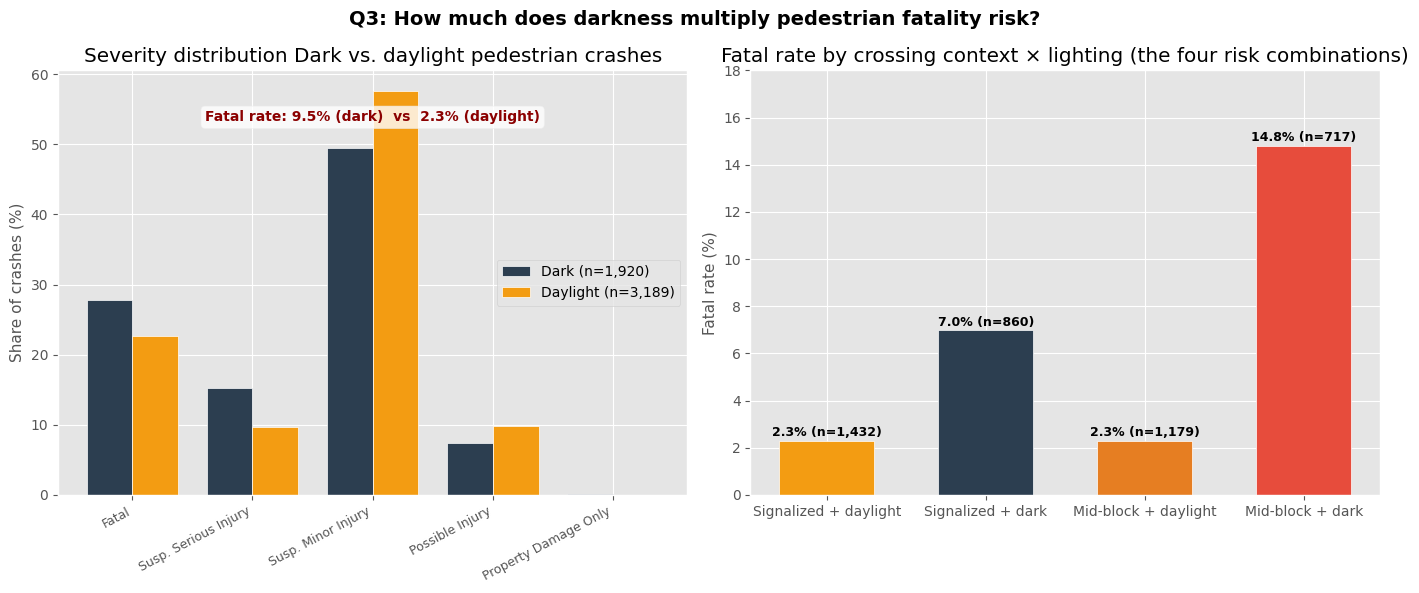

Dark crash fatal rate:     9.53%
Daylight crash fatal rate: 2.29%
Dark multiplier: 4.16×

  Signalized + daylight: 2.3%  (n=1432)
  Signalized + dark: 7.0%  (n=860)
  Mid-block + daylight: 2.3%  (n=1179)
  Mid-block + dark: 14.8%  (n=717)


In [6]:
dark   = ped[ped["illumination_dark"] == 1]
light  = ped[ped["illumination_dark"] == 0]

sev_order = ["Fatal","Susp. Serious Injury","Susp. Minor Injury",
             "Possible Injury","Property Damage Only"]

dark_sev  = (dark["severity"].value_counts(normalize=True)*100).reindex(sev_order, fill_value=0)
light_sev = (light["severity"].value_counts(normalize=True)*100).reindex(sev_order, fill_value=0)

dark_fatal  = dark["fatal"].mean()  * 100
light_fatal = light["fatal"].mean() * 100

# Dark × crossing context interaction
combos = {
    "Signalized + daylight":    ped[(ped["signalized_int"]==1) & (ped["illumination_dark"]==0)],
    "Signalized + dark":        ped[(ped["signalized_int"]==1) & (ped["illumination_dark"]==1)],
    "Mid-block + daylight":     ped[(ped["intersection"]==0)   & (ped["illumination_dark"]==0)],
    "Mid-block + dark":         ped[(ped["intersection"]==0)   & (ped["illumination_dark"]==1)],
}
combo_rates = {k: v["fatal"].mean()*100 for k, v in combos.items()}
combo_ns    = {k: len(v) for k, v in combos.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Q3: How much does darkness multiply pedestrian fatality risk?",
             fontsize=14, fontweight="bold")

# ── Severity: dark vs daylight ────────────────────────────────────────────────
ax = axes[0]
x = np.arange(len(sev_order))
w = 0.38
ax.bar(x - w/2, dark_sev.values,  width=w, label=f"Dark (n={len(dark):,})",
       color="#2c3e50", edgecolor="white")
ax.bar(x + w/2, light_sev.values, width=w, label=f"Daylight (n={len(light):,})",
       color="#f39c12", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(sev_order, rotation=28, ha="right", fontsize=9)
ax.set_ylabel("Share of crashes (%)", fontsize=11)
ax.set_title("Severity distribution Dark vs. daylight pedestrian crashes")
ax.legend(fontsize=10)
ax.text(0.5, 0.88,
        f"Fatal rate: {dark_fatal:.1f}% (dark)  vs  {light_fatal:.1f}% (daylight)",
        transform=ax.transAxes, ha="center", fontsize=10, fontweight="bold",
        color="darkred", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# ── Interaction: crossing context × lighting ──────────────────────────────────
ax = axes[1]
labels = list(combo_rates.keys())
rates  = list(combo_rates.values())
ns     = list(combo_ns.values())
bar_colors = ["#f39c12","#2c3e50","#e67e22","#e74c3c"]
bars = ax.bar(labels, rates, color=bar_colors, edgecolor="white", width=0.6)
ax.set_ylabel("Fatal rate (%)", fontsize=11)
ax.set_title("Fatal rate by crossing context × lighting (the four risk combinations)")
ax.set_ylim(0, 18)
for bar, rate, n in zip(bars, rates, ns):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.2,
            f"{rate:.1f}% (n={n:,})", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("q3_darkness.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Dark crash fatal rate:     {dark_fatal:.2f}%")
print(f"Daylight crash fatal rate: {light_fatal:.2f}%")
print(f"Dark multiplier: {dark_fatal/light_fatal:.2f}×")
print()
for k, v in combo_rates.items():
    print(f"  {k.replace(chr(10),' ')}: {v:.1f}%  (n={combo_ns[k]})")


From this graph, we can see that while more accidents occur during the day, the fatality rate is far higher at night, in spite of there being fewer accidents overall. 

The interaction chart reveals how context and lighting compound, giving us a clear list on what scenario is the most dangerous:
- Signalized intersection + daylight: lowest risk (~2%)
- Signalized intersection + dark: elevated but somewhat mitigated by slower intersection speeds (~4%)
- Mid-block + daylight: already elevated (~5%)
- Mid-block + dark: the most dangerous combination (~12%)

I hypothesize that this ordering arises because of visibility. At a signalized intersection, both the driver and the pedestrian
have some expectation of each other's presence. At a dark mid-block crossing, the pedestrian may not see vehicles coming and the driver has no expectation of a pedestrian in the lane. Thus, they are far less likely to make indications to mitigate disaster, resulting in higher speeds and more dangerous consequences. 

**The practical implication:** wearing visible clothing or carrying a light when crossing at night. When trying to cross mid-block, make sure you are accutely aware of your surroundings, and increase your chances of being visible to any oncoming traffic. 

---
## Q4 — At camera-monitored intersections, which locations have the worst pedestrian crash records?
Finally, we will factor in whether cameras accurately capture the most dangerous intersections. Using a 500-meter spatial radius,
we identify pedestrian crashes that occurred near each of the 23 camera-monitored intersections
with available coordinate data.

The map plots every pedestrian crash citywide, colored by severity,
with camera intersections overlaid as markers sized by the number of pedestrian crashes
recorded nearby. This answers a practical question: of the intersections the city
has already flagged as dangerous enough to warrant enforcement infrastructure,
which are the most dangerous for pedestrians specifically?


In [ ]:
CAMERA_COORDS = {
    "Roosevelt Blvd @ Grant Ave":      (40.0541, -75.0713),
    "Roosevelt Blvd @ Red Lion Rd":    (40.0877, -75.0490),
    "Roosevelt Blvd @ Cottman Ave":    (40.0655, -75.0614),
    "Broad St @ Oregon Ave":           (39.9140, -75.1686),
    "34th St @ Grays Ferry Ave":       (39.9480, -75.1900),
    "Roosevelt Blvd @ Mascher":        (40.0194, -75.1214),
    "Roosevelt Blvd @ Levick St":      (40.0740, -75.0570),
    "Roosevelt Blvd @ Rhawn St":       (40.0796, -75.0531),
    "Roosevelt Blvd @ Welsh Rd":       (40.0817, -75.0509),
    "Roosevelt Blvd @ Southampton Rd": (40.0858, -75.0498),
    "Roosevelt Blvd @ 9th St":         (40.0108, -75.1530),
    "Broad St @ Hunting Park Ave":     (40.0097, -75.1584),
    "58th St @ Walnut St":             (39.9534, -75.2265),
    "City Hall":                       (39.9526, -75.1652),
    "Rising Sun Ave @ Adams Ave":      (40.0455, -75.1003),
    "Aramingo Ave @ Castor Ave":       (40.0005, -75.1068),
    "Aramingo Ave @ York St":          (39.9875, -75.1096),
    "Henry Ave @ Walnut Ln":           (40.0354, -75.2004),
    "Broad St @ Vine St":              (39.9568, -75.1631),
    "Island Ave @ Lindbergh Blvd":     (39.9020, -75.2330),
    "Academy Rd @ Grant Ave":          (40.0560, -75.0210),
    "Bustleton Ave @ Byberry Rd":      (40.1080, -75.0500),
    "Knights Rd @ Woodhaven Rd":       (40.0630, -75.0300),
}
cam_df = pd.DataFrame(
    [{"name": k, "lat": v[0], "lon": v[1]} for k, v in CAMERA_COORDS.items()]
)

def find_camera(lat, lon, threshold=0.0045):
    for _, c in cam_df.iterrows():
        if abs(lat - c["lat"]) < threshold and abs(lon - c["lon"]) < threshold:
            return c["name"]
    return None

# Ped crashes with valid Philly coordinates
ped_map = ped[
    ped["dec_latitude"].between(39.85, 40.15) &
    ped["dec_longitude"].between(-75.30, -74.95)
].copy()

ped_map["camera_int"] = [
    find_camera(r.dec_latitude, r.dec_longitude) for _, r in ped_map.iterrows()
]

# Per-camera pedestrian stats
cam_ped = (ped_map[ped_map["camera_int"].notna()]
           .groupby("camera_int")
           .agg(
               total_ped  =("crn",            "count"),
               fatal_ped  =("fatal",          "sum"),
               dark_ped   =("illumination_dark","sum"),
               hit_run    =("hit_run",         "sum"),
           )
           .reset_index())
cam_ped["fatal_rate"] = cam_ped["fatal_ped"] / cam_ped["total_ped"] * 100
cam_ped = cam_ped.merge(cam_df.rename(columns={"name":"camera_int"}), on="camera_int")

# Load Philly boundary
with open("data/Rubbish_Recyc_Coll_Bnd.geojson") as f:
    bnd = json.load(f)

patches = []
for feat in bnd["features"]:
    geom = feat.get("geometry")
    if not geom: continue
    polys = [geom["coordinates"]] if geom["type"] == "Polygon" else geom["coordinates"]
    for poly in polys:
        ring = poly[0]
        xy = np.array(ring)
        if xy.ndim == 2 and xy.shape[1] >= 2:
            patches.append(MPoly(xy[:, :2], closed=True))

# ── Plot ──────────────────────────────────────────────────────────────────────
SEV_COLORS = {
    "Fatal":                "#e74c3c",
    "Susp. Serious Injury":  "#e67e22",
    "Susp. Minor Injury":    "#f1c40f",
    "Possible Injury":       "#2ecc71",
    "Property Damage Only":  "#bdc3c7",
    "Unknown":               "#95a5a6",
}

fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle(
    "Q4: Pedestrian crashes (2020–2024) and camera-monitored intersections",
    fontsize=13, fontweight="bold"
)

ax.add_collection(PatchCollection(
    patches, facecolor="#f5f5f5", edgecolor="#cccccc", linewidth=0.5
))

# Plot pedestrian crashes, worst severity on top
sev_plot_order = ["Property Damage Only","Unknown","Possible Injury",
                  "Susp. Minor Injury","Susp. Serious Injury","Fatal"]
for sev in sev_plot_order:
    sub = ped_map[ped_map["severity"] == sev]
    ax.scatter(sub["dec_longitude"], sub["dec_latitude"],
               s=8, color=SEV_COLORS[sev], alpha=0.55,
               edgecolors="none", label=f"{sev} (n={len(sub):,})", zorder=2)

# Camera intersections: size = pedestrian crashes nearby, color = fatal rate
max_ped = cam_ped["total_ped"].max()
sc = ax.scatter(
    cam_ped["lon"], cam_ped["lat"],
    s    = (cam_ped["total_ped"] / max_ped) * 350 + 40,
    c    = cam_ped["fatal_rate"],
    cmap = "Reds", vmin=0, vmax=25,
    edgecolors="black", linewidths=0.8,
    zorder=5, label="Camera intersection"
)
plt.colorbar(sc, ax=ax, label="Pedestrian fatal rate at camera site (%)", shrink=0.7)

# Label the top 5 camera sites by pedestrian crash count
for _, row in cam_ped.sort_values("total_ped", ascending=False).head(5).iterrows():
    short = row["camera_int"].replace("Roosevelt Blvd @ ","Roos @ ")
    ax.annotate(short, xy=(row["lon"], row["lat"]),
                xytext=(6, 4), textcoords="offset points",
                fontsize=7, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          edgecolor="gray", alpha=0.85))

ax.set_xlim(-75.30, -74.95)
ax.set_ylim(39.85,  40.15)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)
ax.set_title(
    "Each dot = one pedestrian crash  ·  Circle = camera intersection  ·  "
    "Circle size = ped crash volume  ·  Color = fatal rate",
    fontsize=9
)
ax.legend(fontsize=8, loc="lower left", framealpha=0.9,
          title="Crash severity", title_fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig("q4_map.png", dpi=150, bbox_inches="tight")
plt.show()

print("Camera intersections ranked by pedestrian fatal rate (min 10 crashes):")
print(cam_ped[cam_ped["total_ped"] >= 10]
      .sort_values("fatal_rate", ascending=False)
      [["camera_int","total_ped","fatal_ped","dark_ped","hit_run","fatal_rate"]]
      .to_string(index=False))


Among camera-monitored intersections, **Broad St @ Hunting Park Ave and Roosevelt Blvd @ Mascher
and Aramingo Ave @ York St** show the highest pedestrian fatality rates (15–24%) —
substantially higher than the citywide pedestrian fatal rate of 5%.

**Broad St @ Hunting Park Ave** has a 24% pedestrian fatal rate — nearly 1 in 4 pedestrian crashes
there results in a death. The dark crash count is also the highest proportionally (62% of crashes
there were in dark conditions), suggesting lighting is a critical factor at that site.

The spatial map also reveals that pedestrian crash density extends well beyond the camera network.
Dense clusters of serious and fatal pedestrian crashes appear in West Philadelphia south of Market,
North Philadelphia, and Kensington — areas with no camera coverage at all.
For a pedestrian in those neighborhoods, the enforcement infrastructure that monitors
signal compliance at Roosevelt Blvd is simply irrelevant to their daily safety exposure. This suggests a need for additional infrastructure in these places to prevent unecessary pedestrian deaths. 


### Limitations

**Underreporting:** Not all pedestrian crashes result in a police report.
Minor injury events, especially mid-block, are likely undercounted.
The dataset skews toward crashes serious enough to require police response.

**No exposure data:** We cannot calculate risk per crossing because we do not know
how many pedestrian crossings occur at each location. A high crash count at City Hall
may simply reflect high pedestrian volume rather than high per-crossing danger.

**`time_of_day` is 63% missing.** The hour-level analysis is based on a subset
that may not be representative. Crashes with recorded times may differ systematically
from those without.

### Conclusions

| Finding | What it means for a crossing decision |
|---|---|
| Mid-block fatal rate is ~2× that of signalized intersections | If you must cross outside a crosswalk, do it at a signalized intersection rather than mid-block |
| Dark conditions multiply fatality risk by 4.2× | Wearing visible clothing or carrying a light at night is the single highest-impact individual action |
| Mid-block + dark = 12% fatality rate | This specific combination is extraordinarily dangerous; avoid it |
| Late night (10 PM–2 AM) shows highest per-crash fatality rates | The hours when roads are emptiest are the hours when each car that does pass is most dangerous |
| Friday and Saturday evenings concentrate both volume and severity | Weekend late night is the highest overall risk window |
| Broad St @ Hunting Park Ave: 24% ped fatal rate | Some specific intersections are far more dangerous than the network average even with cameras present |
| Hit-and-run rate in pedestrian crashes is 40% | A vehicle hitting a pedestrian in Philadelphia is nearly as likely to flee as to stop |

Through this data exploration, we get a better sense of what circumstances can minimize the risk of fatality. Overall, try to remain as visible as possible, and look both ways when crossing the street. 